# spatioloji_s — Basic Workflow Tutorial (10x Genomics Xenium)

This notebook covers the complete single-cell processing pipeline for **10x Genomics Xenium** spatial transcriptomics data using **spatioloji_s**.

## Key Xenium differences vs. CosMx / MERFISH

| Feature | Xenium | CosMx |
|---|---|---|
| Loading method | **`from_xenium(dir)`** — one call | `from_files()` with 5 separate files |
| Coordinate unit | **microns (µm)** | pixels |
| Coordinate system | **Single global field — no FOVs** | Per-FOV local + global |
| Expression format | **10x MEX / zarr.zip / tar.gz** (auto-detected) | CSV or NPZ |
| Cell ID column | **`cell_id`** | `cell` |
| Cell area column | **`cell_area`** (µm²) | `Area` (px²) |
| Image | **Single `morphology.ome.tif`** (OME-TIFF pyramid) | Per-FOV JPEGs |
| Negative controls | `NegControlProbe`, `NegControlCodeword`, `DeprecatedCodeword`, `UnassignedCodeword`, `Intergenic` | `NegProbe*` |

## Pipeline overview

```
Load Xenium directory  (sj.spatioloji.from_xenium)
  └─ Quick summary
  └─ Quality control (cells + genes)
     └─ Normalization (library size → log1p → scale)
        └─ Highly variable gene selection
           └─ Dimensionality reduction (PCA → UMAP)
              └─ Clustering (Leiden)
                 └─ Visualization (UMAP + spatial + image overlay)
                    └─ Save
```

## 0. Installation

```bash
pip install spatioloji-s
pip install "spatioloji-s[clustering]"   # Leiden (leidenalg + igraph)
pip install "spatioloji-s[reduction]"    # UMAP
pip install tifffile zarr imagecodecs    # OME-TIFF image support
```

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatioloji_s as sj

print(f"spatioloji_s version: {sj.__version__}")

spatioloji_s version: 0.1.0


---
## 1. Xenium Output Structure

A standard Xenium Onboard Analysis (XOA) output directory contains:

```
output-XeniumRun_<id>/
├── experiment.xenium              # JSON: run metadata, panel info, pixel_size
├── analysis_summary.html          # QC summary report
│
├── cells.csv.gz                   # Per-cell metadata  ← used by from_xenium
├── cell_boundaries.csv.gz         # Cell polygon vertices (µm)  ← used by from_xenium
├── nucleus_boundaries.csv.gz      # Nucleus polygon vertices (µm)
├── transcripts.csv.gz             # Per-transcript table (large; optional)
│
├── cell_feature_matrix/           # 10x MEX sparse format  ← used by from_xenium
│   ├── matrix.mtx.gz              #   genes × cells sparse count matrix
│   ├── barcodes.tsv.gz            #   cell barcodes (= cell_id)
│   └── features.tsv.gz            #   gene_id, gene_name, feature_type
├── cell_feature_matrix.zarr.zip   # Zarr format (alternative)  ← auto-detected
├── cell_feature_matrix.tar.gz     # Tar format (alternative)   ← auto-detected
│
├── morphology.ome.tif             # Whole-tissue DAPI Z-stack (OME-TIFF pyramid)
└── morphology_focus/              # 2D autofocus projections
    ├── morphology_focus_0000.ome.tif
    └── ...
```

### `cells.csv.gz` columns

| Column | Type | Description |
|---|---|---|
| `cell_id` | str | Unique cell identifier (**note: not `cell`**) |
| `x_centroid` | float | X centroid in **µm** |
| `y_centroid` | float | Y centroid in **µm** |
| `transcript_counts` | int | Number of detected gene transcripts |
| `control_probe_counts` | int | NegControlProbe transcript count |
| `control_codeword_counts` | int | NegControlCodeword count |
| `total_counts` | int | All transcripts including controls |
| `cell_area` | float | Cell area in **µm²** |
| `nucleus_area` | float | Nucleus area in **µm²** |

### `cell_boundaries.csv.gz` columns

| Column | Type | Description |
|---|---|---|
| `cell_id` | str | Cell identifier |
| `vertex_x` | float | Vertex X in **µm** |
| `vertex_y` | float | Vertex Y in **µm** |

> **No FOV system:** Xenium captures the entire tissue in a single continuous
> coordinate space. All coordinates are in microns (µm). There are no separate
> FOV tiles — `from_xenium` assigns `fov = "xenium"` as a single dummy FOV.

---
## 2. Load Data

### Option A — Load directly from Xenium output directory (first time)

`from_xenium()` auto-detects the expression format (MTX folder → zarr.zip → tar.gz),
loads cell boundaries as polygons, and stores the OME-TIFF path for later image access.

In [2]:
# Path to your Xenium output directory
xenium_dir = "../../Xenium_5k/"

sp = sj.spatioloji.from_xenium(
    xenium_dir      = xenium_dir,
    load_boundaries = True,     # load cell_boundaries.csv.gz as polygon data
    matrix_type     = "tar",   # auto-detect: MTX folder → zarr.zip → tar.gz
    pixel_size      = 0.2125,   # µm per pixel for the full-res OME-TIFF (instrument default)
    lazy_load_image = True,     # store OME-TIFF path only; load pixels on demand
)
print(sp)


Loading Xenium output → spatioloji
[1] Cell metadata: 1,157,659 cells loaded
[2] Expression matrix (tar.gz): (1157659, 10029)
[3] Cell metadata aligned to expression: 1,157,659 cells
[5] Cell boundaries: 28,934,460 vertices, 1,157,659 cells
[6] OME-TIFF found: morphology.ome.tif (lazy)

Initializing spatioloji
[1/11] Master indices: 1,157,659 cells × 10,029 genes
[2/11] Expression matrix: sparse (10977.9 MB)
[3/10] Cell metadata: 14 columns
[4/11] Gene metadata: 2 columns
[5/11] Spatial coordinates: 1157659 cells
[6/11] Polygons: 28934460 vertices for 1157659 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,157,659
  Genes:              10,029
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14075.8 MB

spatiolo

### Option B — Load a saved object (recommended after first load)

In [ ]:
# sp = sj.spatioloji.from_pickle("my_data/raw_xenium_spatioloji.pkl")
# print(sp)

---
## 3. Quick Summary

In [3]:
sj.data.utils.quick_summary(sp)


SPATIOLOJI SUMMARY
Cells:                 1,157,659
Genes:                    10,029
FOVs:                          1
Images:                        0 (0 loaded)
--------------------------------------------------
Avg cells/FOV:         1157659.0
Expression format:        Sparse
Sparsity:                 91.7%
Has polygons:                Yes
Memory usage:           14075.8 MB



In [4]:
print("Cell meta columns:", sp.cell_meta.columns.tolist())
print(f"\nCells  : {sp.n_cells:,}")
print(f"Genes  : {sp.n_genes:,}")
print(f"FOVs   : {sp.n_fovs}  (always 1 for Xenium — single global coordinate space)")

# Xenium-specific attributes stored by from_xenium
print(f"\nXenium directory  : {sp._xenium_dir}")
print(f"OME-TIFF path     : {sp._xenium_image_path}")
print(f"Pixel size (µm/px): {sp._xenium_pixel_size}")

Cell meta columns: ['x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'fov']

Cells  : 1,157,659
Genes  : 10,029
FOVs   : 1  (always 1 for Xenium — single global coordinate space)

Xenium directory  : ../../Xenium_5k
OME-TIFF path     : ../../Xenium_5k/morphology.ome.tif
Pixel size (µm/px): 0.2125


In [5]:
# Identify negative-control genes in the expression matrix.
# Xenium uses five prefixes for non-biological features:
#   NegControlProbe     — off-target probe binding (background signal)
#   NegControlCodeword  — erroneous barcode decoding
#   DeprecatedCodeword  — retired codewords from older panel versions
#   UnassignedCodeword  — valid codewords not assigned to any gene
#   Intergenic          — transcripts decoded outside annotated gene bodies
NEG_PREFIXES = (
    "NegControlProbe",
    "NegControlCodeword",
    "DeprecatedCodeword",
    "UnassignedCodeword",
    "Intergenic",
)

neg_genes  = [g for g in sp.gene_index if g.startswith(NEG_PREFIXES)]
real_genes = [g for g in sp.gene_index if not g.startswith(NEG_PREFIXES)]

print(f"Total features      : {sp.n_genes:,}")
print(f"Panel genes         : {len(real_genes):,}")
print(f"Negative controls   : {len(neg_genes):,}")
print(f"\nControl gene names  : {neg_genes}")

Total features      : 10,029
Panel genes         : 5,001
Negative controls   : 5,028

Control gene names  : ['NegControlProbe_00013', 'NegControlProbe_00016', 'NegControlProbe_00074', 'NegControlProbe_00012', 'NegControlProbe_00051', 'NegControlProbe_00054', 'NegControlProbe_00009', 'NegControlProbe_00017', 'NegControlProbe_00025', 'NegControlProbe_00057', 'NegControlProbe_00059', 'NegControlProbe_00060', 'NegControlProbe_00039', 'NegControlProbe_00024', 'NegControlProbe_00040', 'NegControlProbe_00053', 'NegControlProbe_00046', 'NegControlProbe_00028', 'NegControlProbe_00044', 'NegControlProbe_00062', 'NegControlProbe_00035', 'NegControlProbe_00041', 'NegControlProbe_00073', 'NegControlProbe_00002', 'NegControlProbe_00034', 'NegControlProbe_00003', 'NegControlProbe_00014', 'NegControlProbe_00042', 'NegControlProbe_00069', 'NegControlProbe_00004', 'NegControlProbe_00058', 'NegControlProbe_00067', 'NegControlProbe_00033', 'NegControlProbe_00019', 'NegControlProbe_00043', 'NegControlProbe

---
## 4. Quality Control

### Xenium QC differences vs. CosMx

| QC metric | Xenium | CosMx |
|---|---|---|
| Cell area column | **`cell_area`** (µm²) | `Area` (px²) |
| Negative control prefixes | `NegControlProbe`, `NegControlCodeword`, `DeprecatedCodeword`, `UnassignedCodeword`, `Intergenic` | `NegProbe` |
| FOV-level QC | **Not applicable** (single coordinate space) | `qc_fov_metrics` |
| Typical counts/cell | 50–500 (sparse panel) | 100–2,000 |

### Xenium negative-control gene types

| Prefix | Biological meaning | Use in QC |
|---|---|---|
| `NegControlProbe` | Off-target probe binding | Primary background measure |
| `NegControlCodeword` | Erroneous barcode decoding | Decoding error rate |
| `DeprecatedCodeword` | Retired codewords (old panel versions) | Carry-over artefact |
| `UnassignedCodeword` | Valid codewords with no gene assignment | Panel coverage metric |
| `Intergenic` | Transcripts outside annotated gene bodies | Annotation / segmentation artefact |

> **Tip:** Xenium panels are typically smaller (300–5,000 genes) with lower per-cell
> counts than CosMx. Adjust `total_counts_min` accordingly (10–50 is typical).

In [6]:
NEG_PREFIXES = (
    "NegControlProbe",
    "NegControlCodeword",
    "DeprecatedCodeword",
    "UnassignedCodeword",
    "Intergenic",
)

qc_config = sj.XeniumQCConfig(
    neg_prefixes              = NEG_PREFIXES,
    # Cell filters
    transcript_counts_min     = 10,     # min panel-gene transcripts per cell
    n_features_min            = 5,      # min unique genes detected
    pct_counts_neg_max        = 0.05,   # max 5% from any control type (XOA: warn 4%, error 10%)
    pct_counts_mt_max         = 0.25,   # max 25% mitochondrial
    cell_area_min             = 20.0,   # µm²  — remove debris
    cell_area_max             = 500.0,  # µm²  — remove putative doublets
    nucleus_cell_ratio_max    = 1.0,    # remove segmentation errors
    # Gene filters
    gene_filter_method        = "percentile",
    gene_percentile_threshold = 50,     # keep genes above 50th pct of ctrl baseline
    output_dir                = "./xenium_qc_output/",
    save_plots                = True,
)

In [7]:
qc = sj.xenium_qc(sp, config=qc_config)

  Gene annotations: 5,001 panel genes, 5,028 control features
    NegControlProbe: 40
    NegControlCodeword: 609
    DeprecatedCodeword: 3291
    UnassignedCodeword: 1067
    Intergenic: 21
Calculating Xenium QC metrics...
  Calculated QC metrics for 1,157,659 cells


In [8]:
# xenium_qc.__init__ automatically computes QC columns and adds them to sp.cell_meta.
# Preview all metrics that were added:
qc_cols = [
    c for c in sp.cell_meta.columns
    if c.startswith((
        "pct_counts_",
        "n_features",
        "total_counts_expr",
        "transcript_counts_expr",
        "nucleus_cell_ratio",
        "transcript_density",
        "QC_",
        "is_neg_ctrl",
        "neg_ctrl_type",
    ))
]
print(f"QC metrics added to cell_meta ({len(qc_cols)} columns):")
print(qc_cols)
sp.cell_meta[qc_cols].describe().round(4)

QC metrics added to cell_meta (12 columns):
['total_counts_expr', 'transcript_counts_expr', 'n_features_by_counts', 'pct_counts_neg', 'pct_counts_mt', 'pct_counts_NegControlProbe', 'pct_counts_NegControlCodeword', 'pct_counts_DeprecatedCodeword', 'pct_counts_UnassignedCodeword', 'pct_counts_Intergenic', 'nucleus_cell_ratio', 'transcript_density']


,total_counts_expr,transcript_counts_expr,n_features_by_counts,pct_counts_neg,pct_counts_mt,pct_counts_NegControlProbe,pct_counts_NegControlCodeword,pct_counts_DeprecatedCodeword,pct_counts_UnassignedCodeword,pct_counts_Intergenic,nucleus_cell_ratio,transcript_density
count,1.157659e+06,1.157659e+06,1.157659e+06,1.157659e+06,1157659.0,1.157659e+06,1.157659e+06,1.157659e+06,1.157659e+06,1.157659e+06,1.111031e+06,1.157659e+06
mean,1.671331e+03,1.668298e+03,8.260485e+02,1.700000e-03,0.0,0.000000e+00,0.000000e+00,1.600000e-03,0.000000e+00,0.000000e+00,5.500000e-01,1.671420e+01
std,1.244289e+03,1.241766e+03,4.177950e+02,2.100000e-03,0.0,3.000000e-04,1.000000e-04,2.000000e-03,2.000000e-04,2.000000e-04,1.716000e-01,6.778500e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.060000e-02,0.000000e+00
25%,7.310000e+02,7.300000e+02,5.090000e+02,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.371000e-01,1.281850e+01
50%,1.403000e+03,1.401000e+03,8.180000e+02,1.400000e-03,0.0,0.000000e+00,0.000000e+00,1.300000e-03,0.000000e+00,0.000000e+00,5.637000e-01,1.815540e+01
75%,2.358000e+03,2.353000e+03,1.135000e+03,2.400000e-03,0.0,0.000000e+00,0.000000e+00,2.300000e-03,0.000000e+00,0.000000e+00,6.701000e-01,2.153420e+01
max,2.152000e+04,2.140600e+04,2.684000e+03,5.000000e-01,0.0,5.260000e-02,1.350000e-02,5.000000e-01,1.250000e-01,9.090000e-02,1.000000e+00,5.283120e+01


In [9]:
# --- Option A: run all steps at once ---
# sp_filtered = qc.run_qc_pipeline(plot=True)

# --- Option B: run steps individually for more control ---

# Cell & nucleus area (debris < 20 µm², doublets > 500 µm², ratio > 1 = seg. error)
qc.qc_cell_area(plot=True)

# Transcript count + feature diversity distributions
qc.qc_transcript_metrics(plot=True)

# Per-type control fraction breakdown (NegControlProbe, NegControlCodeword, etc.)
qc.qc_control_metrics(plot=True)

# Nucleus : cell area ratio — segmentation quality
qc.qc_nucleus_cell_ratio(plot=True)

# Transcript density — spatial uniformity (transcripts / µm²)
qc.qc_transcript_density(plot=True)

# polygon check — polygon invalidity
qc.qc_polygon_validity(plot=True)


[Xenium QC] Cell & Nucleus Area
  cell_area range  : 2.0 -- 879.2 um2
  Median cell_area : 87.6 um2
  Cells passing    : 1,135,534 / 1,157,659 (98.1%)

[Xenium QC] Transcript Metrics
  Median transcript_counts     : 1401
  Median n_features          : 818
  Median pct_counts_neg      : 0.14%
  Cells with < 10 transcripts: 872
  Cells with < 5 features    : 298

[Xenium QC] Control Feature Metrics
  Type                                   Mean %   Median %     Max %
  -----------------------------------  --------  ---------  --------
  pct_counts_neg                          0.168      0.136    50.000
  pct_counts_NegControlProbe              0.002      0.000     5.263
  pct_counts_NegControlCodeword           0.002      0.000     1.351
  pct_counts_DeprecatedCodeword           0.160      0.127    50.000
  pct_counts_UnassignedCodeword           0.004      0.000    12.500
  pct_counts_Intergenic                   0.001      0.000     9.091

  XOA alert -- cells >= 4%  (warning threshold

,n_vertices,area,is_valid,shapely_reason
cell_id,,,,
aaaaapbh-1,25,66.492795,True,
aaaabakn-1,25,164.820648,True,
aaaabhic-1,25,59.877610,True,
aaaabngi-1,25,91.238671,True,
aaaabnhl-1,25,128.288905,True,
...,...,...,...,...
oilnefna-1,25,125.516196,True,
oilnenmm-1,25,35.335116,True,
oilnfbml-1,25,120.859556,True,


In [10]:
# filter_cells() applies all thresholds from XeniumQCConfig and prints per-filter counts.
# Pass custom_filters for additional per-column thresholds.
cell_mask = qc.filter_cells(
    custom_filters={
        # Add extra per-column filters if needed, e.g.:
        # "transcript_density": (0.01, None),  # min 0.01 tx/µm²
    }
)

# filter_genes() excludes all control genes, then applies panel-gene filter
gene_mask = qc.filter_genes(plot=True)

print(f"\nCells passing QC: {cell_mask.sum():,} / {len(cell_mask):,}")
print(f"Genes passing QC: {gene_mask.sum():,} / {len(gene_mask):,}")


[Xenium QC] Filtering Cells
  Before : 1,157,659 cells
  After  : 1,134,555 cells (98.0% kept)

  Cells failing each individual filter (counts may overlap):
    transcript_counts < 10                            : 872
    n_features < 5                                    : 298
    pct_neg > 5%                                      : 86
    pct_mt > 25%                                      : 0
    cell_area < 20.0 um2                              : 22,011
    cell_area > 500.0 um2                             : 114
    nucleus_cell_ratio > 1.0                          : 0
    invalid polygon geometry                          : 752

[Xenium QC] Filtering Genes (method=percentile)
  Filter criterion   : 50th pct of ctrl baseline (81.0 counts)
  Panel genes before : 5,001
  Panel genes kept   : 5,001 (100.0%)
  Control genes      : 5,028  (excluded from output)

Cells passing QC: 1,134,555 / 1,157,659
Genes passing QC: 5,001 / 10,029


In [11]:
# Print a tabular QC summary and save to JSON + bar chart
qc.summarize_qc(plot=True)


XENIUM QC SUMMARY

Cells  : 1,157,659 -> 1,134,555 (98.0% kept)
  Fail transcript_counts < 10: 872
  Fail n_features < 5: 298
  Fail pct_neg > 5%: 86
  Fail pct_mt > 25%: 0
  Fail cell_area < 20.0 um2: 22,011
  Fail cell_area > 500.0 um2: 114
  Fail nucleus_cell_ratio > 1.0: 0
  Fail invalid polygon geometry: 752

Genes  : 5,001 panel -> 5,001 kept (100.0%); 5,028 ctrl excluded


{'timestamp': '2026-03-13 06:16:20',
 'n_cells_input': 1157659,
 'n_genes_input': 10029,
 'metrics': {'cell_area':              cell_area  nucleus_area  nucleus_cell_ratio  area_pass
  cell_id                                                            
  aaaaapbh-1   69.901878     46.872189            0.670543       True
  aaaabakn-1  168.161881     69.540628            0.413534       True
  aaaabhic-1   62.451096     57.619377            0.922632       True
  aaaabngi-1   95.234535     35.899220            0.376956       True
  aaaabnhl-1  131.088599     83.042347            0.633483       True
  ...                ...           ...                 ...        ...
  oilnefna-1  128.559848     35.131564            0.273270       True
  oilnenmm-1   37.479689      8.760313            0.233735       True
  oilnfbml-1  126.256880     49.175158            0.389485       True
  oilngggn-1  107.562191     61.502815            0.571788       True
  oilnghpk-1    8.173282      8.173282         

In [12]:
sp_filtered = qc.apply_filters()

print(f"Before QC: {sp.n_cells:,} cells, {sp.n_genes:,} genes")
print(f"After QC : {sp_filtered.n_cells:,} cells, {sp_filtered.n_genes:,} genes")


Applying Xenium QC filters...

Subsetting by cells: 1134555 cells requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 10,029 genes
[2/11] Expression matrix: sparse (10929.1 MB)
[3/10] Cell metadata: 30 columns
[4/11] Gene metadata: 11 columns
[5/11] Spatial coordinates: 1134555 cells
[6/11] Polygons: 28363705 vertices for 1134555 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,134,555
  Genes:              10,029
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14287.0 MB

✓ Created subset: 1134555 cells, 1 FOVs

Subsetting by genes: 5001 genes requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 5,001 genes
[2/11] Expression matrix: sparse (10899.5 MB)
[3/10] Cell

In [13]:
os.makedirs("xenium_data", exist_ok=True)
sp_filtered.to_pickle("xenium_data/filtered_xenium_spatioloji.pkl")
del sp_filtered


Saving spatioloji to: xenium_data/filtered_xenium_spatioloji.pkl
✓ Saved (12639.6 MB)


---
## 5. Normalization

Same three-step workflow as CosMx. Library-size normalisation to 10,000 (CPM-equivalent)
followed by log1p and z-score scaling for PCA.

In [3]:
sp = sj.data.spatioloji.from_pickle("xenium_data/filtered_xenium_spatioloji.pkl")


Loading spatioloji from: xenium_data/filtered_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes


In [4]:
# Step 1 — library-size normalisation
sj.processing.normalize_total(sp, target_sum=1e4, inplace=True)
# Adds layer: 'normalized_counts'

# Step 2 — log1p transform
sj.processing.log_transform(sp, layer="normalized_counts", inplace=True)
# Adds layer: 'log_normalized'

# Step 3 — z-score scaling (PCA input only; do NOT use for DE / violin plots)
sj.processing.scale(sp, layer="log_normalized", max_value=10.0, inplace=True, zero_center=False)
# Adds layer: 'scaled'

print("Available layers:", sp.list_layers())


Normalizing expression to target sum: 10,000
  Counts per cell — mean: 1697, median: 1431
  ✓ Normalized 1,134,555 cells × 5,001 genes
✓ Added layer 'normalized_counts' (sparse, 7267.8 MB)

Applying log transformation (base=e)
  ✓ Transformed 1,134,555 cells × 5,001 genes
✓ Added layer 'log_normalized' (sparse, 7267.8 MB)

Scaling expression data (method: standard)
  Clipped stored values to [-10.0, 10.0]
  ✓ Scaled 1,134,555 cells × 5,001 genes (sparse output)
✓ Added layer 'scaled' (sparse, 7267.8 MB)
Available layers: ['normalized_counts', 'log_normalized', 'scaled']


---
## 6. Highly Variable Gene (HVG) Selection

For Xenium panels (typically 300–5,000 genes) with sparse counts, the **deviance** method
is recommended. If the panel is small (<500 genes), skip HVG selection and use all genes.

In [6]:
n_panel_genes = sp.n_genes
n_top_genes   = min(1000, n_panel_genes)

if n_panel_genes <= 500:
    # Small panel — use all genes for PCA
    sp.gene_meta["highly_variable"] = True
    print(f"Panel ≤ 500 genes — using all {n_panel_genes} genes")
else:
    # Deviance: designed for sparse count data, best for Xenium panels
    sj.processing.highly_variable_genes(
        sp,
        layer       = "log_normalized",
        method      = "seurat_v3",
        n_top_genes = n_top_genes,
        inplace     = True,
    )
    n_hvg = sp.gene_meta["highly_variable"].sum()
    print(f"HVGs selected: {n_hvg} / {n_panel_genes}")


Identifying highly variable genes (method=seurat_v3)
  Using Seurat v3 VST method (n_top_genes=1000)
  ✓ Selected 1000 highly variable genes
    Mean expression range: 0.000 - 2.493
HVGs selected: 1000 / 5001


In [9]:
# Optional: compare multiple HVG methods to check consistency
if n_panel_genes > 500:
    hvg_comparison = sj.processing.compare_hvg_methods(
        sp,
        methods     = ["seurat_v3", "deviance", "pearson_residuals"],
        n_top_genes = n_top_genes,
        layers       = ["log_normalized", None, None],
    )
    consensus_genes = hvg_comparison.index[hvg_comparison["consensus"]].tolist()
    print(f"Consensus HVGs (majority vote): {len(consensus_genes)}")
    hvg_comparison.sort_values("n_methods_selected", ascending=False).head(20)


Comparing 3 HVG methods (n_jobs=1)
  seurat_v3                    layer='log_normalized'
  deviance                     layer='None'
  pearson_residuals            layer='None'

Running: seurat_v3  (layer='log_normalized')

Identifying highly variable genes (method=seurat_v3)
  Using Seurat v3 VST method (n_top_genes=1000)
  ✓ Selected 1000 highly variable genes
    Mean expression range: 0.000 - 2.493

Running: deviance  (layer='None')

Identifying highly variable genes (method=deviance)
  Using binomial deviance method (n_top_genes=1000)
  ✓ Selected 1000 highly variable genes
    Mean expression range: 0.166 - 31.184

Running: pearson_residuals  (layer='None')

Identifying highly variable genes (method=pearson_residuals)
  Using Pearson residuals method (n_top_genes=1000)
  ✓ Selected 1000 highly variable genes
    Mean expression range: 0.000 - 31.184

HVG Method Comparison Summary
  n_top_genes per method : 1000
  Methods run            : ['seurat_v3', 'deviance', 'pearson_residu

---
## 7. Dimensionality Reduction

### 7a. PCA


Computing PCA (n_comps=50)
  Using 1000 highly variable genes
  Running PCA...
  ✓ PCA complete
    Variance explained by first 10 PCs: 20.5%
    Variance explained by all 50 PCs: 29.2%


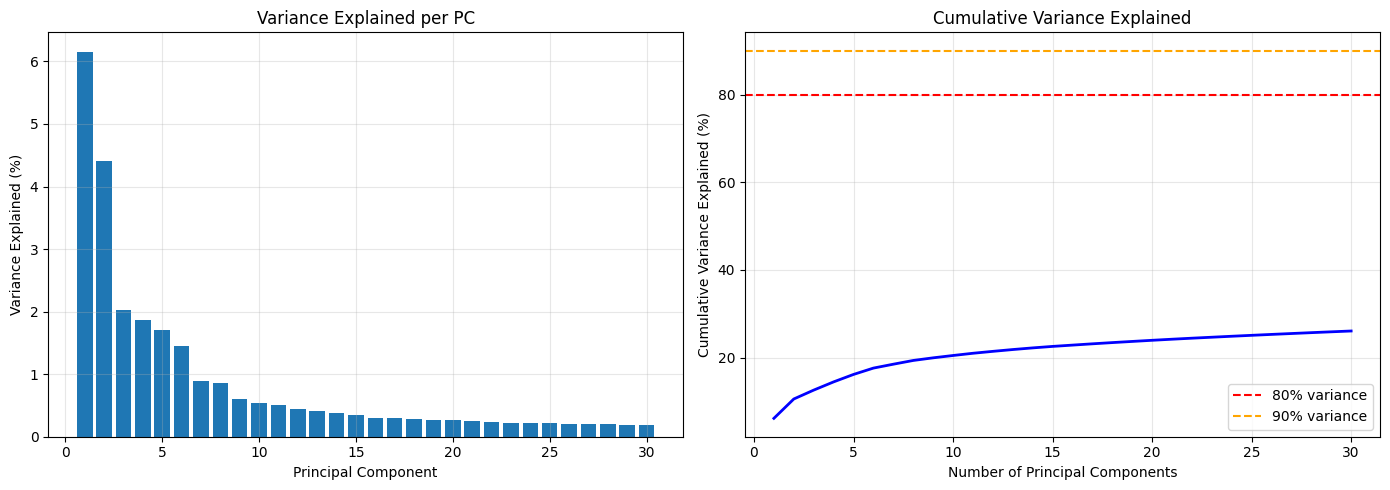


PCA Variance Summary:
  PCs needed for 80% variance: 30
  PCs needed for 90% variance: 30
  Total variance (first 30 PCs): 26.1%


In [10]:
sj.processing.pca(
    sp,
    layer               = "scaled",
    use_highly_variable = True,
    n_comps             = 50,
    random_state        = 42,
    inplace             = True,
)

sj.processing.plot_pca_variance(sp, n_pcs=30)

### 7b. UMAP

In [11]:
# Requires: pip install "spatioloji-s[reduction]"
sj.processing.umap(
    sp,
    use_pca      = True,
    n_pcs        = 20,
    n_neighbors  = 30,
    min_dist     = 0.3,
    random_state = 42,
    inplace      = True,
)
# Stores UMAP1 / UMAP2 in sp.cell_meta and X_umap in sp._embeddings

/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-13 06:39:03.392592: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 06:39:07.934118: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 06:39:13.439770: I tensorflow/c


UMAP (n_components=2, n_neighbors=30, min_dist=0.3)
  Using first 20 PCs as input
  Running UMAP...


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ✓ UMAP complete


---
## 8. Clustering

### 8a. Leiden resolution sweep

In [3]:
sweep_df = sj.processing.leiden_resolution_sweep(
    sp,
    resolutions  = list(np.arange(0.2, 1.6, 0.2)),
    n_runs       = 3,
    n_pcs        = 20,
    n_neighbors  = 30,
    random_state = 42,
    n_jobs = 21
)
sweep_df

  Using stored PCA (first 20 PCs)
  Building umap connectivity graph...
    Using pynndescent (approximate KNN)...

Leiden resolution sweep (7 resolutions × 3 runs = 21 calls, graph=umap)
  Resolution  n_clusters   mean_ARI  modularity
  ----------------------------------------------


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


        0.20         9.7     0.8817      0.8121
        0.40        10.7     0.8095      0.8215
        0.60        15.3     0.6941      0.8407
        0.80        18.3     0.6464      0.8414
        1.00        21.7     0.6718      0.8418
        1.20        25.3     0.6885      0.8384
        1.40        27.3     0.6850      0.8370

  Most stable resolution: 0.20  (mean ARI=0.8817)


,resolution,n_clusters_mean,n_clusters_min,n_clusters_max,mean_ari,std_ari,modularity_mean
0,0.2,9.666667,9,10,0.881656,0.011986,0.812129
1,0.4,10.666667,10,11,0.809490,0.048898,0.821541
2,0.6,15.333333,15,16,0.694063,0.010505,0.840663
3,0.8,18.333333,17,20,0.646377,0.039020,0.841386
4,1.0,21.666667,21,22,0.671811,0.040983,0.841766
5,1.2,25.333333,24,26,0.688546,0.028249,0.838404
6,1.4,27.333333,26,29,0.684959,0.013332,0.836995


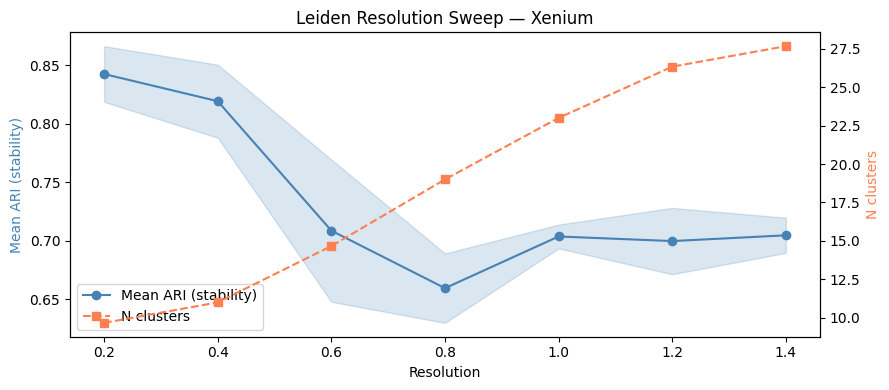

In [6]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(sweep_df["resolution"], sweep_df["mean_ari"], "o-", color="steelblue", label="Mean ARI (stability)")
ax1.fill_between(
    sweep_df["resolution"],
    sweep_df["mean_ari"] - sweep_df["std_ari"],
    sweep_df["mean_ari"] + sweep_df["std_ari"],
    alpha=0.2, color="steelblue",
)
ax2.plot(sweep_df["resolution"], sweep_df["n_clusters_mean"], "s--", color="coral", label="N clusters")

ax1.set_xlabel("Resolution")
ax1.set_ylabel("Mean ARI (stability)", color="steelblue")
ax2.set_ylabel("N clusters", color="coral")
ax1.set_title("Leiden Resolution Sweep — Xenium")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")
plt.tight_layout()
plt.savefig("xenium_data/leiden_resolution_sweep.pdf", bbox_inches="tight")
plt.show()

In [7]:
optimal_res = float(sweep_df.loc[sweep_df["mean_ari"].idxmax(), "resolution"])
print(f"Most stable resolution: {optimal_res}")
# Override if you prefer a specific cluster count:
# optimal_res = 0.5

Most stable resolution: 0.2


### 8b. Run Leiden clustering

In [14]:
sj.processing.leiden_clustering(
    sp,
    layer               = "scaled",
    use_highly_variable = True,
    resolution          = 0.2,
    n_neighbors         = 30,
    n_pcs               = 20,
    use_pca             = True,
    random_state        = 42,
    output_column       = "leiden",
    inplace             = True,
)

print(f"Leiden clusters: {sp.cell_meta['leiden'].nunique()}")
print(sp.cell_meta["leiden"].value_counts().sort_index())


Leiden clustering (resolution=0.2, n_neighbors=30, graph=umap)
  Using 1000 highly variable genes (out of 5001 total)
  Using stored PCA (first 20 PCs)
  Building umap connectivity graph...
  Running Leiden algorithm...
  ✓ Found 9 clusters
    Cluster sizes - min: 33806, max: 278929, mean: 126061.7
Leiden clusters: 9
leiden
0    278929
1    272748
2    138097
3    133860
4     90374
5     88695
6     54227
7     43819
8     33806
Name: count, dtype: int64


### 8c. Assess clustering quality

In [15]:
metrics = sj.processing.assess_clustering_quality(
    sp,
    cluster_col = "leiden",
    layer       = "scaled",
    n_pcs       = 30,
    sample_size = 5000,
)

for k, v in metrics.items():
    if k != "cluster_sizes":
        print(f"  {k}: {v}")


Clustering quality for 'leiden' (9 clusters):
  Silhouette score:        +0.1520  (higher = better, max 1.0)
  Davies-Bouldin index:    1.6043   (lower = better, min 0.0)
  Calinski-Harabasz index: 158022.74  (higher = better)
  Cluster sizes - min: 33806, max: 278929, mean: 126061.7
  n_clusters: 9
  silhouette: 0.15198193490505219
  davies_bouldin: 1.6043452323218166
  calinski_harabasz: 158022.73800706078


---
## 9. UMAP Visualization

### 9a. UMAP coloured by cluster

Saved to xenium_plots/UMAP_leiden.png


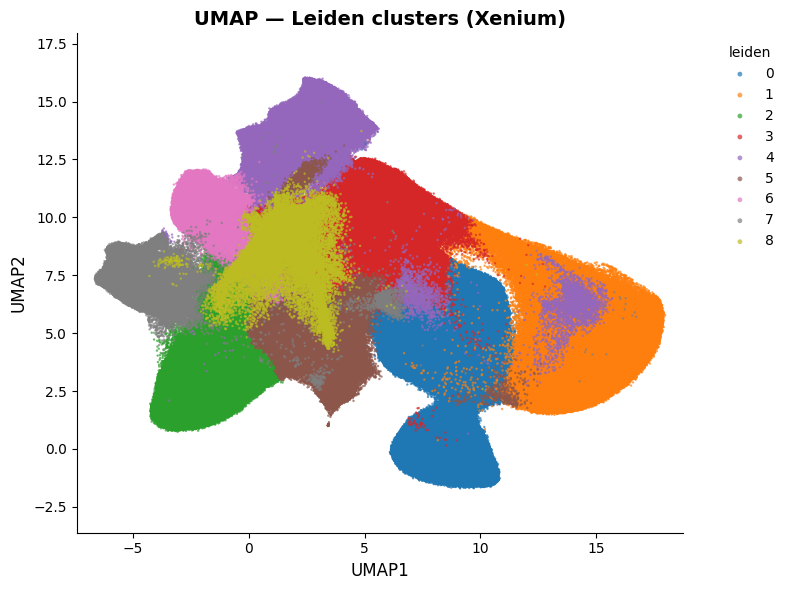

In [21]:
os.makedirs("xenium_plots", exist_ok=True)

FANCY_COLORS = [
    "#1f77b4", 
    "#ff7f0e",  
    "#2ca02c",  
    "#d62728",  
    "#9467bd", 
    "#8c564b",  
    "#e377c2",  
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

def generate_leiden_color_dict(leiden_series, palette=None):
    """
    Generate a color dictionary for categorical Leiden clusters.

    Parameters
    ----------
    leiden_series : pd.Series
        Leiden cluster labels (e.g. sp.cell_meta['leiden'])
    palette : list[str], optional
        List of hex colors.

    Returns
    -------
    dict
        {cluster_label: color}
    """
    import pandas as pd

    if palette is None:
        palette = FANCY_COLORS

    clusters = sorted(pd.unique(leiden_series.astype(str)))

    if len(clusters) > len(palette):
        raise ValueError(
            f"Palette only has {len(palette)} colors but {len(clusters)} clusters found."
        )

    color_dict = {cluster: palette[i] for i, cluster in enumerate(clusters)}

    return color_dict

color_dict = generate_leiden_color_dict(sp.cell_meta.leiden)


sj.visualization.plot_umap(
    sp,
    color_by   = "leiden",
    color_map    = color_dict,
    point_size = 3.0,
    title      = "UMAP — Leiden clusters (Xenium)",
    show       = True,
    save_path  = "xenium_plots/UMAP_leiden.png",
)

Saved to xenium_plots/UMAP_transcript_counts.png


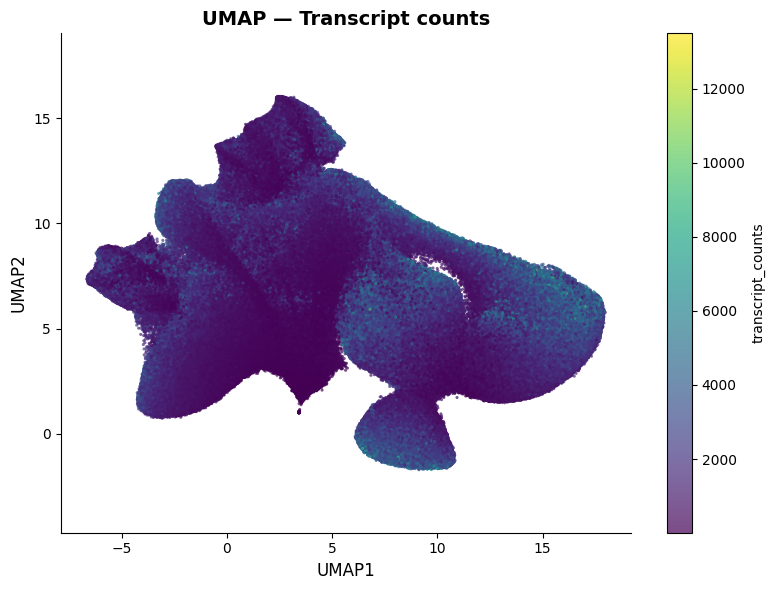

In [22]:
# transcript_counts: gene transcripts only (excludes negative controls)
sj.visualization.plot_umap(
    sp,
    color_by  = "transcript_counts",
    color_map = "viridis",
    title     = "UMAP — Transcript counts",
    show      = True,
    save_path = "xenium_plots/UMAP_transcript_counts.png",
)

Saved to xenium_plots/UMAP_EPCAM.png


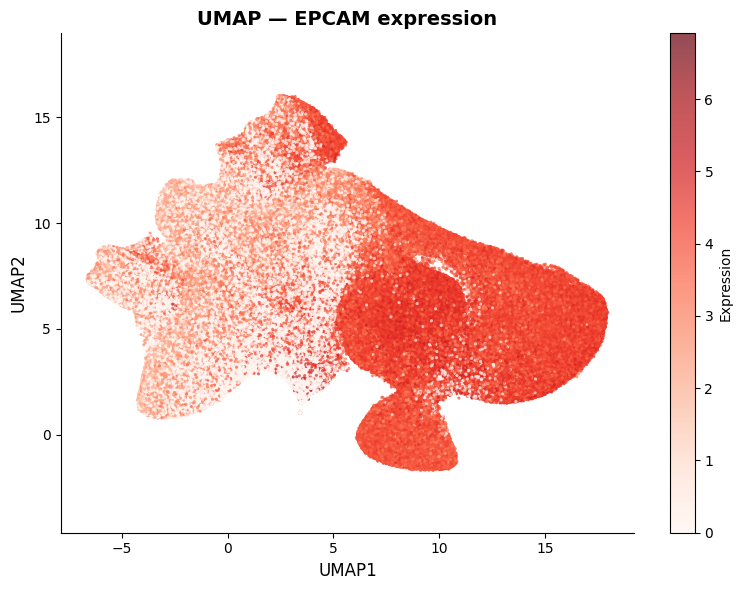

In [23]:
# Gene expression overlay — replace 'EPCAM' with a gene from your panel
sj.visualization.plot_umap(
    sp,
    gene      = "EPCAM",
    layer     = "log_normalized",
    color_map = "Reds",
    title     = "UMAP — EPCAM expression",
    show      = True,
    save_path = "xenium_plots/UMAP_EPCAM.png",
)

### 9b. Multi-panel UMAP grid

Saved to xenium_plots/UMAP_grid.png


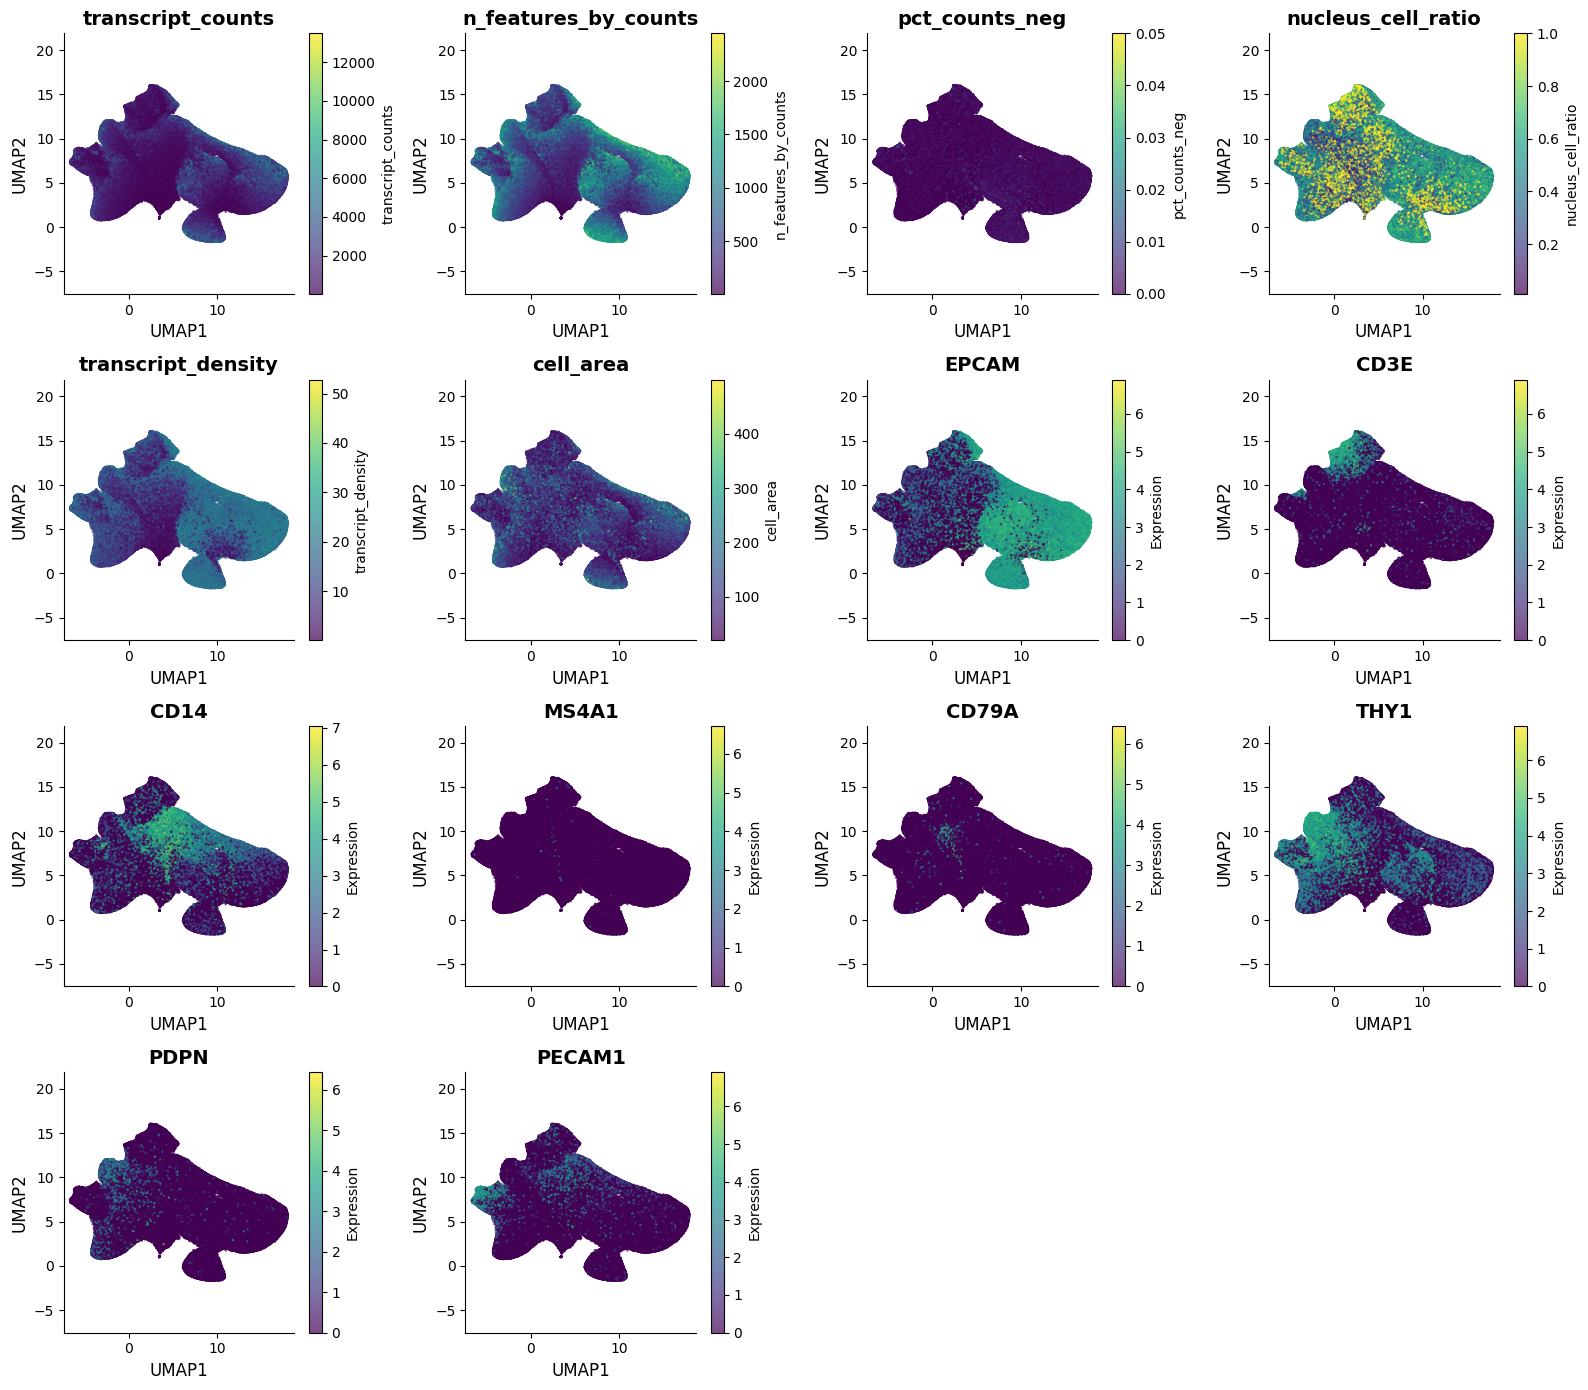

In [24]:
# Adjust gene list to markers present in your Xenium panel.
# Also overlay QC-derived columns to spot technical outliers per cluster.
sj.visualization.plot_umap_grid(
    sp,
    genes    = ["EPCAM", "CD3E", "CD14", "MS4A1", "CD79A", "THY1", "PDPN", "PECAM1"],
    features = [
        "transcript_counts",       # library size (raw)
        "n_features_by_counts",    # gene diversity
        "pct_counts_neg",          # aggregate negative-control fraction
        "nucleus_cell_ratio",      # segmentation quality
        "transcript_density",      # spatial expression density (tx/µm²)
        "cell_area",               # cell size
    ],
    ncols    = 4,
    layer    = "log_normalized",
    show     = True,
    save_path = "xenium_plots/UMAP_grid.png",
)

### 9c. Violin, heatmap, dot plots

Saved to xenium_plots/violin_markers.png


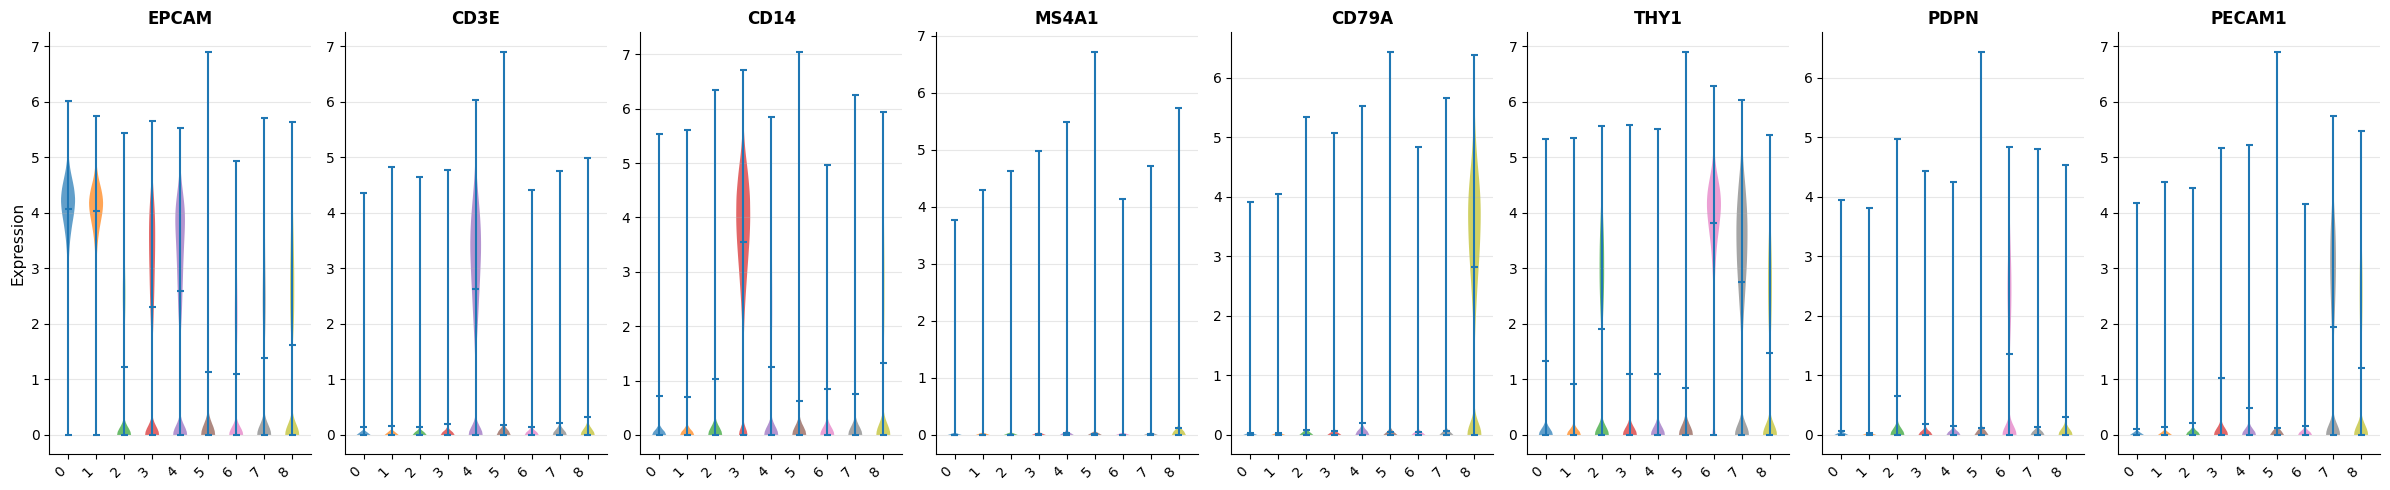

In [27]:
marker_genes = ["EPCAM", "CD3E", "CD14", "MS4A1", "CD79A", "THY1", "PDPN", "PECAM1"]
marker_genes = [g for g in marker_genes if g in sp.gene_index.tolist()]

sj.visualization.plot_violin(
    sp,
    genes    = marker_genes,
    group_by = "leiden",
    layer    = "log_normalized",
    show     = True,
    save_path = "xenium_plots/violin_markers.png",
    color_map = color_dict
)

Saved to xenium_plots/heatmap_markers.png


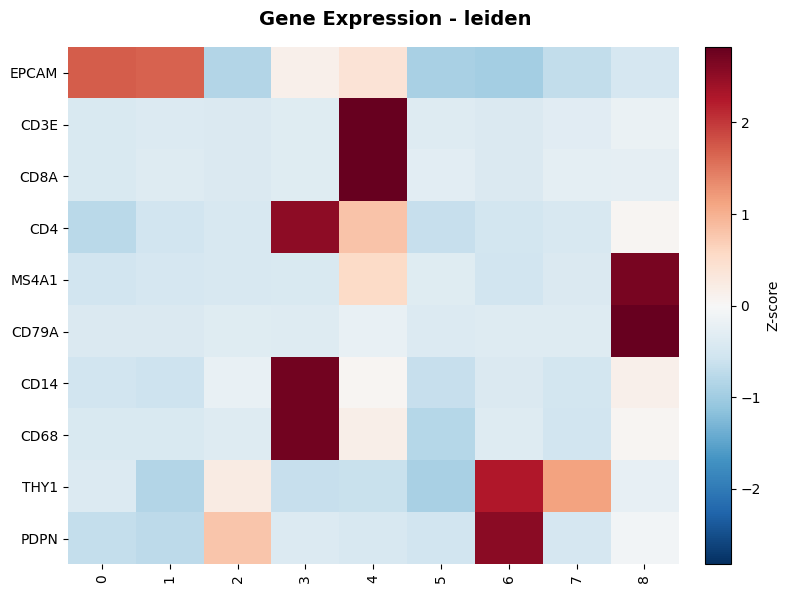

In [28]:
gene_order = [
    "EPCAM", "KRT18", "KRT19",          # Epithelial
    "CD3D", "CD3E", "CD8A", "CD4",      # T cells
    "MS4A1", "CD79A",                    # B cells
    "CD14", "CD68",               # Myeloid
    "THY1", "PDPN",                   # Fibroblast
]
gene_order    = [g for g in gene_order if g in sp.gene_index.tolist()]
cluster_order = [str(i) for i in sorted(sp.cell_meta["leiden"].unique())]

sj.visualization.plot_heatmap(
    sp,
    genes       = gene_order,
    group_by    = "leiden",
    gene_order  = gene_order,
    group_order = cluster_order,
    scale       = "row",
    layer       = "log_normalized",
    show        = True,
    save_path   = "xenium_plots/heatmap_markers.png",
)

Saved to xenium_plots/dotplot_markers.png


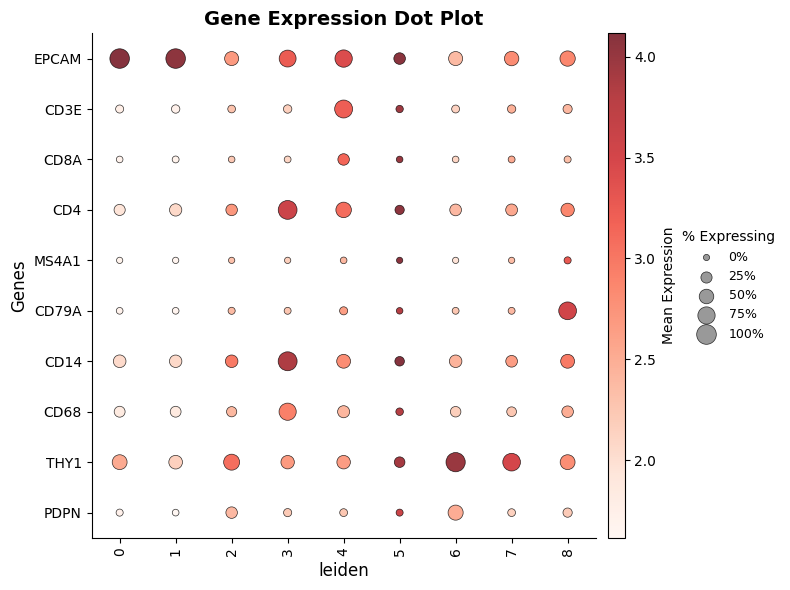

In [29]:
sj.visualization.plot_dotplot(
    sp,
    genes      = gene_order,
    gene_order = gene_order,
    group_by   = "leiden",
    layer      = "log_normalized",
    show       = True,
    save_path  = "xenium_plots/dotplot_markers.png",
)

---
## 10. Spatial Visualization

Xenium data lives in a **single continuous coordinate space** (µm), so all spatial
plots use global coordinates directly. The OME-TIFF pyramid stored in
`sp._xenium_image_path` can be opened at any resolution level via
`sp.get_xenium_image(level=...)` — level `"0"` is full resolution,
higher levels are progressively downsampled (factor 2× per level).

### 10a. Spatial scatter — cluster map

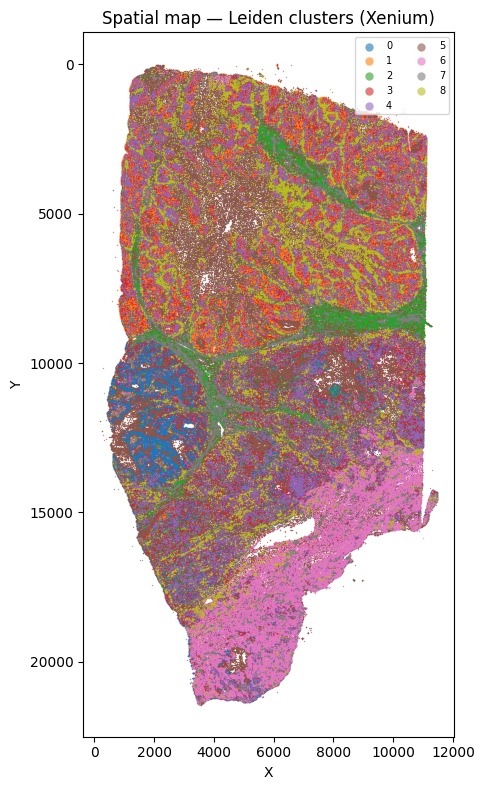

In [30]:
cluster_ids     = sp.cell_meta["leiden"].astype(str)
unique_clusters = sorted(cluster_ids.unique())

# Example: color_dict = {"0":"#4E79A7", "1":"#F28E2B", ...}
# If you already generated it earlier, just reuse it

fig, ax = plt.subplots(figsize=(10, 8))

for cl in unique_clusters:
    mask = cluster_ids == cl
    ax.scatter(
        sp.cell_meta.loc[mask, "x_centroid"],
        sp.cell_meta.loc[mask, "y_centroid"],
        s=1,
        c=color_dict[cl],
        label=cl,
        alpha=0.6,
        linewidths=0,
    )

ax.set_aspect("equal")
ax.invert_yaxis()          # OME-TIFF origin is top-left; match image convention
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Spatial map — Leiden clusters (Xenium)")

ax.legend(
    markerscale=6,
    loc="upper right",
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.savefig("xenium_plots/spatial_leiden.png", bbox_inches="tight")
plt.show()

### 10b. Spatial gene expression/protein staning map

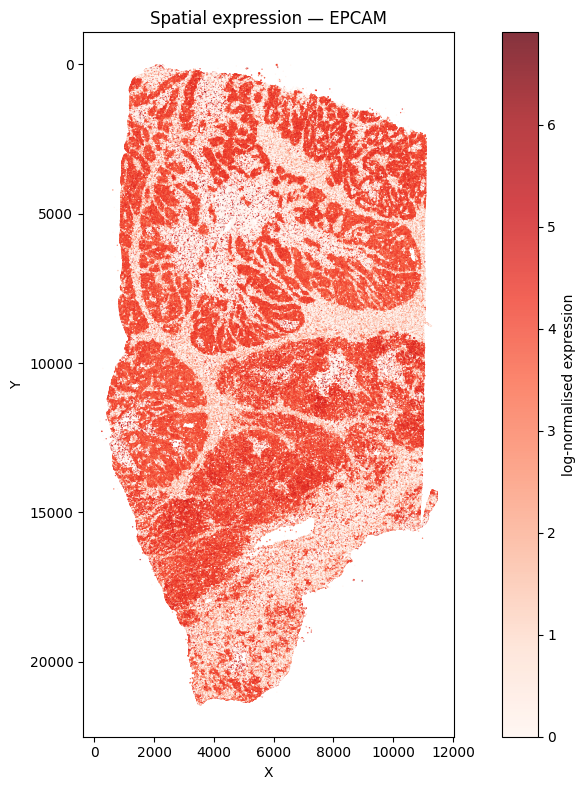

In [32]:
gene = "EPCAM"   # replace with a gene in your panel

if gene in sp.gene_index:
    gene_expr = sp.get_expression(gene_names = gene, layer="log_normalized")

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(
        sp.cell_meta["x_centroid"],
        sp.cell_meta["y_centroid"],
        c=gene_expr, cmap="Reds", s=1, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="log-normalised expression")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial expression — {gene}")
    plt.tight_layout()
    plt.savefig(f"xenium_plots/spatial_{gene}.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{gene} not in panel — replace with a gene from sp.gene_index")

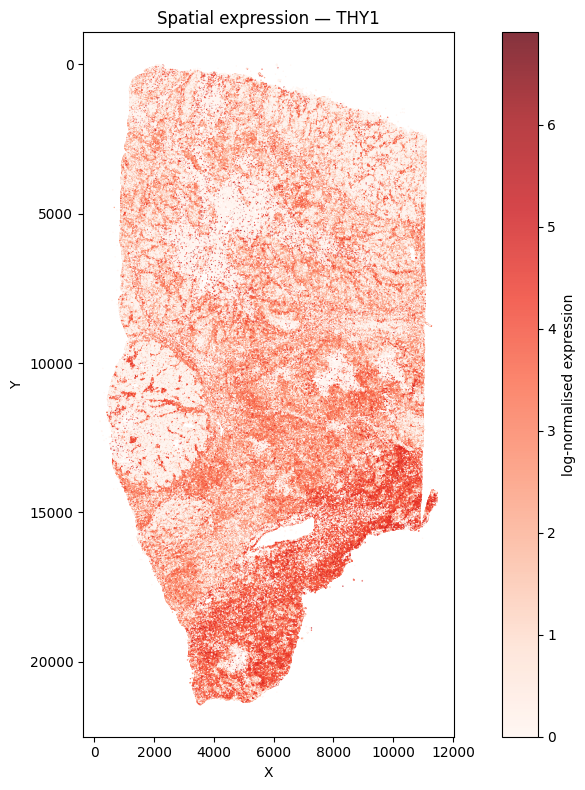

In [33]:
gene = "THY1"   # replace with a gene in your panel

if gene in sp.gene_index:
    gene_expr = sp.get_expression(gene_names = gene, layer="log_normalized")

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(
        sp.cell_meta["x_centroid"],
        sp.cell_meta["y_centroid"],
        c=gene_expr, cmap="Reds", s=1, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="log-normalised expression")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial expression — {gene}")
    plt.tight_layout()
    plt.savefig(f"xenium_plots/spatial_{gene}.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{gene} not in panel — replace with a gene from sp.gene_index")

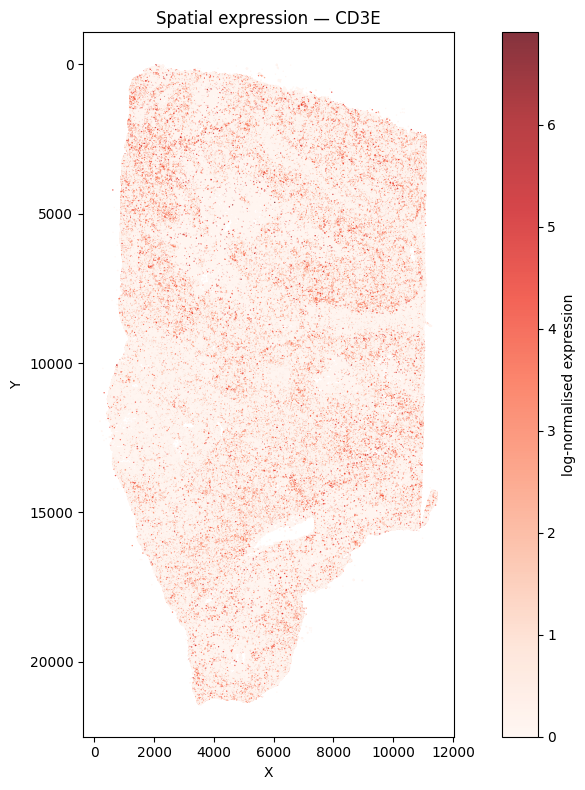

In [34]:
gene = "CD3E"   # replace with a gene in your panel

if gene in sp.gene_index:
    gene_expr = sp.get_expression(gene_names = gene, layer="log_normalized")

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(
        sp.cell_meta["x_centroid"],
        sp.cell_meta["y_centroid"],
        c=gene_expr, cmap="Reds", s=1, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="log-normalised expression")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial expression — {gene}")
    plt.tight_layout()
    plt.savefig(f"xenium_plots/spatial_{gene}.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{gene} not in panel — replace with a gene from sp.gene_index")

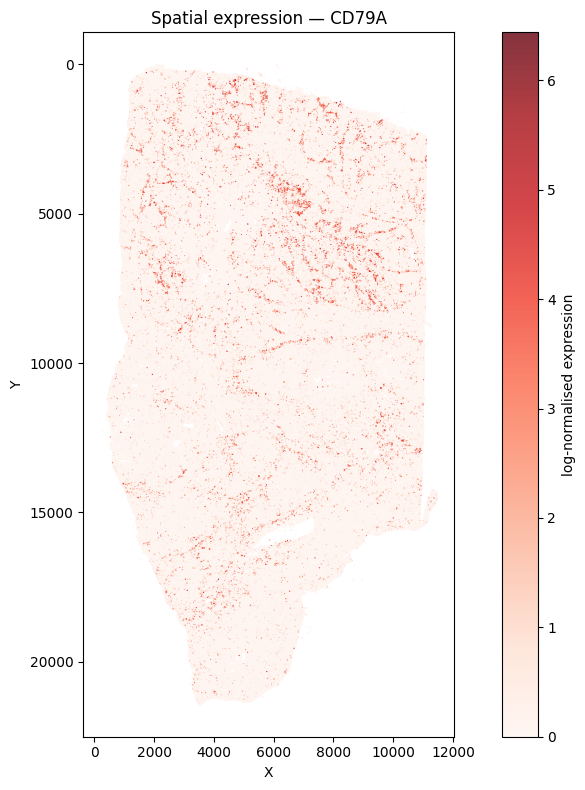

In [4]:
gene = "CD79A"   # replace with a gene in your panel

if gene in sp.gene_index:
    gene_expr = sp.get_expression(gene_names = gene, layer="log_normalized")

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(
        sp.cell_meta["x_centroid"],
        sp.cell_meta["y_centroid"],
        c=gene_expr, cmap="Reds", s=1, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="log-normalised expression")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial expression — {gene}")
    plt.tight_layout()
    plt.savefig(f"xenium_plots/spatial_{gene}.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{gene} not in panel — replace with a gene from sp.gene_index")

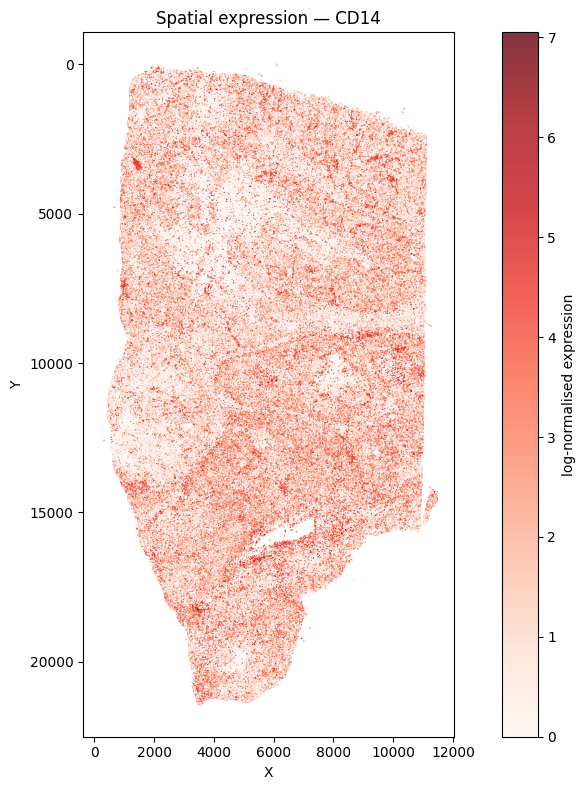

In [5]:
gene = "CD14"   # replace with a gene in your panel

if gene in sp.gene_index:
    gene_expr = sp.get_expression(gene_names = gene, layer="log_normalized")

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(
        sp.cell_meta["x_centroid"],
        sp.cell_meta["y_centroid"],
        c=gene_expr, cmap="Reds", s=1, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="log-normalised expression")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial expression — {gene}")
    plt.tight_layout()
    plt.savefig(f"xenium_plots/spatial_{gene}.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{gene} not in panel — replace with a gene from sp.gene_index")

### 10c. Cell overlay on the OME-TIFF morphology image


| Level | Effective pixel size |
|---|---|
| `"0"` | 0.2125 µm/px (full res) |
| `"2"` | ~0.85 µm/px |
| `"3"` | ~1.70 µm/px |
| `"4"` | ~3.40 µm/px |
| `"5"` | ~6.80 µm/px |
| `"6"` | ~13.60 µm/px |
| `"7"` | ~27.20 µm/px |

> Use level `"3"` or `"4"` for whole-tissue overview plots.  
> Use level `"0"` or `"1"` only for small ROI crops (full array is very large).

  Saved: xenium_plots/xenium_staining_dapi_level3.png


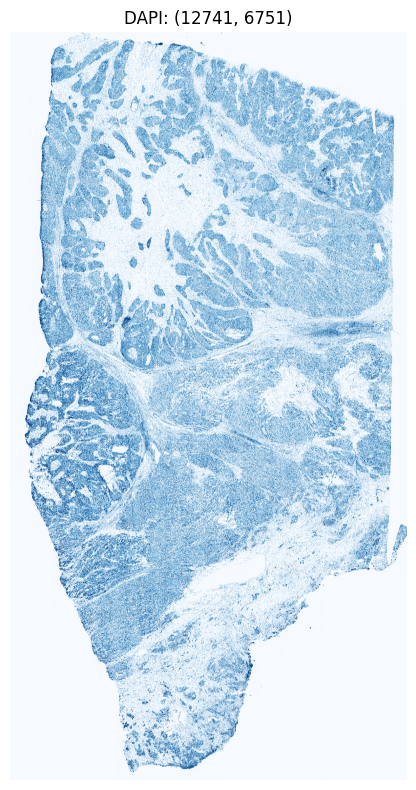

In [6]:
sj.visualization.xenium_show_staining(
  '../../Xenium_5k/morphology_focus/morphology_focus_0000.ome.tif', channels='dapi', cmaps='Blues',
  level=3, save_dir='xenium_plots')

  Saved: xenium_plots/xenium_staining_boundary_membrane_level3.png


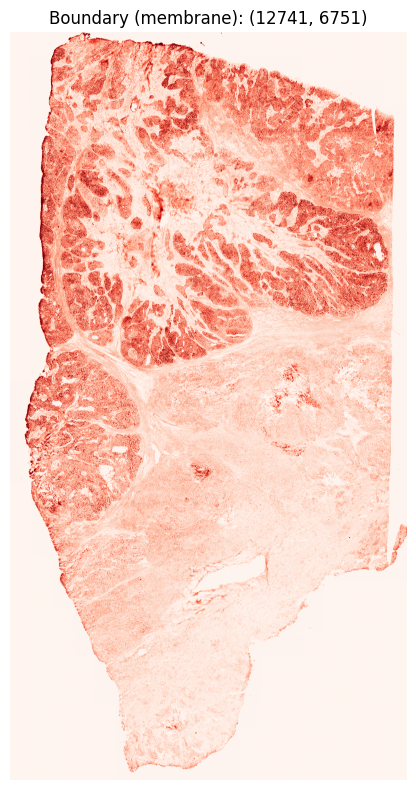

In [7]:
sj.visualization.xenium_show_staining(
  '../../Xenium_5k/morphology_focus/morphology_focus_0001.ome.tif', channels='boundary', cmaps='Reds',
  level=3, save_dir='xenium_plots')

  Saved: xenium_plots/xenium_staining_boundary_membrane_level5.png


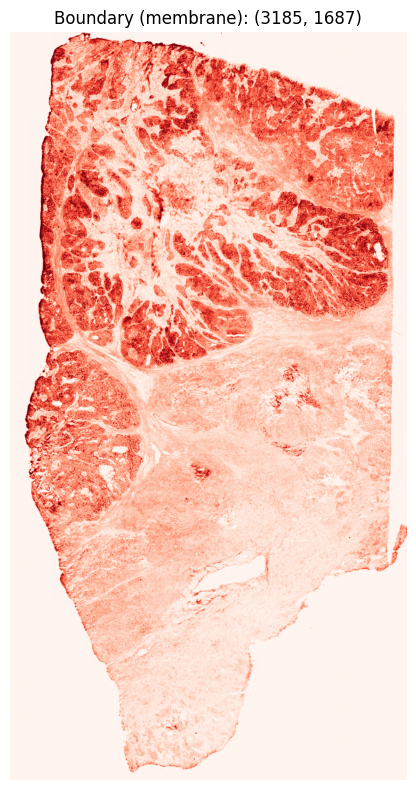

In [8]:
sj.visualization.xenium_show_staining(
  '../../Xenium_5k/morphology_focus/morphology_focus_0001.ome.tif', channels='boundary', cmaps='Reds',
  level=5, save_dir='xenium_plots')

  Saved: xenium_plots/xenium_staining_interior_18s_rna_level3.png


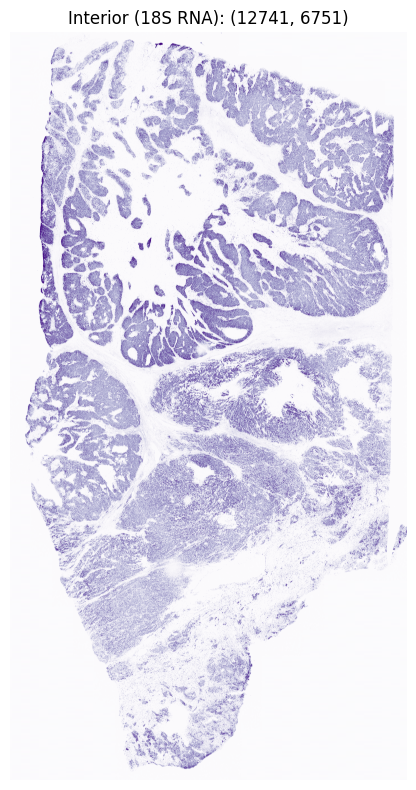

In [5]:
sj.visualization.xenium_show_staining(
  '../../Xenium_5k/morphology_focus/morphology_focus_0002.ome.tif', channels='interior', cmaps='Purples',
  level=3, save_dir='xenium_plots')

  Saved: xenium_plots/xenium_staining_protein_if_level3.png


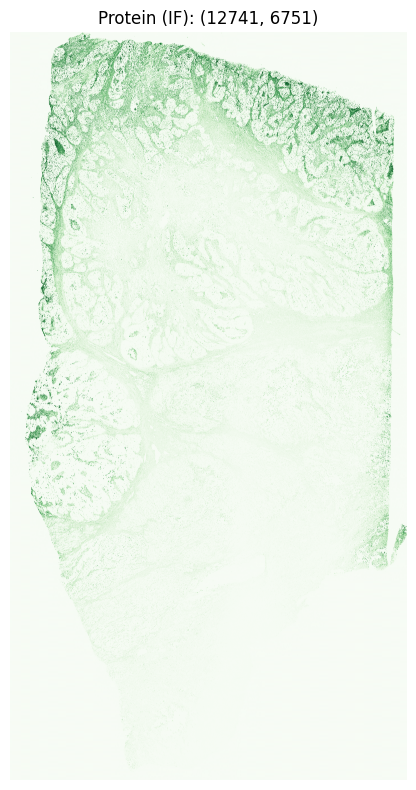

In [6]:
sj.visualization.xenium_show_staining(
  '../../Xenium_5k/morphology_focus/morphology_focus_0003.ome.tif', channels='protein', cmaps='Greens',
  level=3, save_dir='xenium_plots')

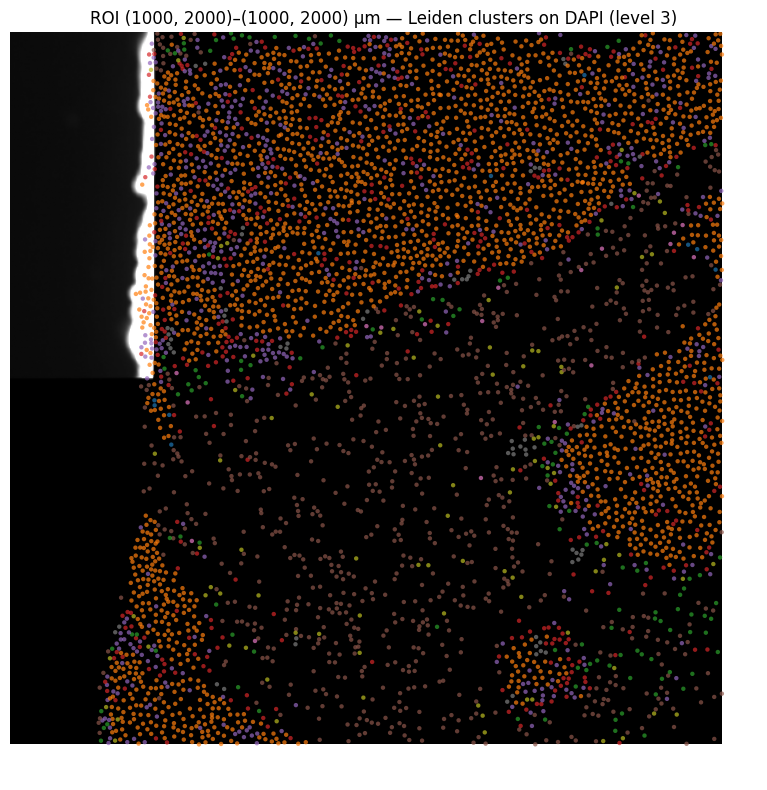

In [38]:
# --- ROI crop example ---
# Select a region in µm and convert to pixel coordinates at the chosen level

# Define ROI in µm (adjust to a region of interest in your data)
roi_x_um = (1000, 2000)   # µm
roi_y_um = (1000, 2000)   # µm

# Convert to pixel coordinates at this level
roi_x_px = (int(roi_x_um[0] / px_size), int(roi_x_um[1] / px_size))
roi_y_px = (int(roi_y_um[0] / px_size), int(roi_y_um[1] / px_size))

dapi_crop = dapi[roi_y_px[0]:roi_y_px[1], roi_x_px[0]:roi_x_px[1]]

# Filter cells in this ROI
roi_mask = (
    (sp.cell_meta["x_centroid"] >= roi_x_um[0]) &
    (sp.cell_meta["x_centroid"] <  roi_x_um[1]) &
    (sp.cell_meta["y_centroid"] >= roi_y_um[0]) &
    (sp.cell_meta["y_centroid"] <  roi_y_um[1])
)
roi_meta = sp.cell_meta[roi_mask]

# Convert ROI cell coordinates to cropped-image pixel coordinates
roi_x_px_cells = (roi_meta["x_centroid"].values - roi_x_um[0]) / px_size
roi_y_px_cells = (roi_meta["y_centroid"].values - roi_y_um[0]) / px_size
roi_colors     = [color_dict[cl] for cl in roi_meta["leiden"].astype(str)]

fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = np.percentile(dapi_crop, [1, 99])
ax.imshow(dapi_crop, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
ax.scatter(roi_x_px_cells, roi_y_px_cells, c=roi_colors, s=10, alpha=0.7, linewidths=0)
ax.set_title(f"ROI {roi_x_um}–{roi_y_um} µm — Leiden clusters on DAPI (level {LEVEL})")
ax.axis("off")
plt.tight_layout()
plt.savefig("xenium_plots/spatial_leiden_roi.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 11. Save the Final Object

In [16]:
sp.to_pickle("xenium_data/processed_xenium_spatioloji.pkl")
print("Saved.")


Saving spatioloji to: xenium_data/processed_xenium_spatioloji.pkl
✓ Saved (34894.2 MB)
Saved.


In [2]:
# optional
sp = sj.data.core.spatioloji.from_pickle("xenium_data/processed_xenium_spatioloji.pkl")
print("optional load")


Loading spatioloji from: xenium_data/processed_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes
optional load


In [17]:
print("=" * 55)
print("Processed Xenium object summary")
print("=" * 55)
print(f"  Cells           : {sp.n_cells:,}")
print(f"  Genes           : {sp.n_genes:,}")
print(f"  Layers          : {sp.list_layers()}")
print(f"  Leiden clusters : {sp.cell_meta['leiden'].nunique()}")
print(f"  OME-TIFF        : {sp._xenium_image_path}")
print("\nNext steps:")
print("  → spatial_analysis_xenium.ipynb — neighbourhood enrichment, Moran's I, Ripley K")
print("  → ccc_xenium.ipynb              — cell-cell communication (3-layer polygon framework)")

Processed Xenium object summary
  Cells           : 1,134,555
  Genes           : 5,001
  Layers          : ['normalized_counts', 'log_normalized', 'scaled']
  Leiden clusters : 9
  OME-TIFF        : ../../Xenium_5k/morphology.ome.tif

Next steps:
  → spatial_analysis_xenium.ipynb — neighbourhood enrichment, Moran's I, Ripley K
  → ccc_xenium.ipynb              — cell-cell communication (3-layer polygon framework)


---
## 12. DEG analysis

In [8]:
sp.cell_meta['cell_group'] = sp.cell_meta.leiden.astype(str)
sp.cell_meta['cell_group']

cell_id
aaaaapbh-1    1
aaaabakn-1    1
aaaabhic-1    4
aaaabngi-1    1
aaaabnhl-1    1
             ..
oilncghd-1    2
oilnefna-1    2
oilnenmm-1    5
oilnfbml-1    5
oilngggn-1    5
Name: cell_group, Length: 1134555, dtype: object

In [9]:
# --- 1. Quick Wilcoxon test: one cell type vs all others ---
results = sj.processing.deg_wilcoxon(
  sp,
  groupby="cell_group",
  group_fg="1",        # foreground group
  group_bg="rest",         # compare against all other cells
)
# results is a dict: {"wilcoxon": pd.DataFrame}
df = results["wilcoxon"]
print(df.head(10))
# Columns: gene, log2fc, pval, pval_adj, mean_fg, mean_bg, pct_fg, pct_bg

# Filter significant DEGs
sig = df[(df["padj"] < 0.05) & (df["log2fc"].abs() > 1)]
print(f"Found {len(sig)} significant DEGs")


# --- 2. Pairwise comparison ---
results = sj.processing.deg_ttest(
  sp,
  groupby="cell_group",
  group_fg="1",
  group_bg="5",      # specific background group
)


# --- 3. Run multiple methods at once ---
results = sj.processing.run_deg(
  sp,
  groupby="cell_group",
  group_fg="1",
  group_bg="rest",
  methods=["wilcoxon", "ttest"],
  n_jobs=4,                # parallelize Wilcoxon
)
# results keys: {"wilcoxon": DataFrame, "ttest": DataFrame}


# --- 4. Spatial filter: only cells in a region ---
results = sj.processing.deg_wilcoxon(
  sp,
  groupby="cell_group",
  group_fg="1",
  group_bg="5",
  spatial_filter={"bbox": [100, 100, 800, 800]},  # [xmin, ymin, xmax, ymax]
) # it will pop up errors if no cells selected


# --- 5. DESeq2 pseudobulk (requires replicate labels) ---
#results = sj.processing.deg_deseq2(
#  sp,
#  groupby="leiden",
#  group_fg=1,
#  group_bg=6,
#  replicate_key="sample_id",  # column in cell_metadata with replicate/sample IDs
#)



Running DEG [wilcoxon]: 272748 fg vs 861807 bg, 5001 genes
  ✓ wilcoxon: 4825 significant genes (padj < 0.05)
       gene    log2fc   mean_fg   mean_bg    pct_fg    pct_bg  pval  padj  \
0    SLC2A1  1.051890  3.354558  1.618024  0.797194  0.470971   0.0   0.0   
1      LDLR  0.674376  0.339643  0.212821  0.239356  0.157026   0.0   0.0   
2   LDLRAD4 -0.948563  0.041225  0.079562  0.038259  0.072197   0.0   0.0   
3   SLC35E1  1.486036  2.349337  0.838695  0.803812  0.445182   0.0   0.0   
4   SLC35G2 -1.931892  0.004708  0.017962  0.004605  0.016434   0.0   0.0   
5   SLC37A4  0.713260  0.295185  0.180045  0.240779  0.148916   0.0   0.0   
6  SLC39A11  0.667704  0.491666  0.309508  0.356769  0.227057   0.0   0.0   
7   SLC39A9  0.658707  0.337385  0.213715  0.269153  0.180683   0.0   0.0   
8    SLC3A2  0.249292  1.393070  1.172003  0.642831  0.516873   0.0   0.0   
9   SLC40A1 -0.887680  0.302976  0.560565  0.209871  0.271814   0.0   0.0   

     n_fg    n_bg  
0  272748  861807  
1

ValueError: spatial_filter must contain 'polygon', 'x_range', or 'y_range'

Key points:
- groupby: column name in sp.cell_metadata that defines cell groups
- group_fg: the group(s) you're interested in (foreground)
- group_bg: "rest" (all other cells) or a specific group name
- All methods return dict[str, pd.DataFrame] sorted by pval_adj ascending
- Wilcoxon and t-test need no extra dependencies; MAST/NB-GLM need statsmodels; DESeq2 needs pydeseq2

---
## Appendix: Xenium Reference

### `from_xenium()` parameter reference

| Parameter | Default | Description |
|---|---|---|
| `xenium_dir` | — | Path to Xenium output directory |
| `load_boundaries` | `True` | Load `cell_boundaries.csv.gz` as polygon data |
| `matrix_type` | `"auto"` | `"auto"` / `"mtx"` / `"zarr"` / `"tar"` |
| `pixel_size` | `0.2125` | µm per pixel for the full-res OME-TIFF |
| `lazy_load_image` | `True` | Store OME-TIFF path only; load on demand |

### `get_xenium_image(level)` reference

| Level | Pixel size (µm/px) | Recommended use |
|---|---|---|
| `"0"` | 0.2125 (full res) | Small ROI crops only |
| `"1"` | 0.425 | Medium ROI |
| `"2"` | 0.85 | Large ROI |
| `"3"` | 1.70 | **Whole-tissue overview** |
| `"4"` | 3.40 | Fast whole-tissue thumbnail |

Returns shape **(n_channels, H, W)**. Channel 0 is typically DAPI.

### `XeniumQCConfig` parameter reference

| Parameter | Default | Description |
|---|---|---|
| `neg_prefixes` | 5-tuple of all control prefixes | Control gene prefixes to exclude |
| `transcript_counts_min` | `10` | Min panel-gene transcripts per cell |
| `n_features_min` | `5` | Min unique genes detected per cell |
| `pct_counts_neg_max` | `0.05` | Max fraction of any control type (XOA: warn 4%, error 10%) |
| `pct_counts_mt_max` | `0.25` | Max mitochondrial fraction |
| `cell_area_min` | `20.0` | Min cell area (µm²) — remove debris |
| `cell_area_max` | `500.0` | Max cell area (µm²) — remove doublets |
| `nucleus_cell_ratio_max` | `1.0` | Max nucleus:cell area ratio — remove segmentation errors |
| `gene_filter_method` | `"percentile"` | `"percentile"` / `"absolute"` / `"min_cells"` |
| `gene_percentile_threshold` | `50` | Keep genes above this percentile of ctrl baseline |
| `gene_min_cells` | `None` | Min cells expressing gene (used when method=`"min_cells"`) |
| `output_dir` | `"./xenium_qc_output/"` | Directory for saved plots and JSON report |
| `save_plots` | `True` | Whether to auto-save figures to `output_dir` |

### `xenium_qc` method reference

| Method | Description |
|---|---|
| `qc_cell_area(plot)` | Cell area + nucleus area histograms, nucleus:cell scatter |
| `qc_transcript_metrics(plot)` | Transcript count + gene diversity distributions |
| `qc_control_metrics(plot)` | Per-type control fraction bar chart + violin (XOA thresholds) |
| `qc_nucleus_cell_ratio(plot)` | Ratio histogram + CDF; flags ratio > 1.0 |
| `qc_transcript_density(plot)` | Density histogram + spatial scatter coloured by tx/µm² |
| `filter_cells(custom_filters)` | Apply all thresholds; print per-filter failure counts |
| `filter_genes(plot)` | Exclude controls; filter panel genes by configured method |
| `summarize_qc(plot)` | Print table, save JSON report, plot cell-counts bar chart |
| `apply_filters(filter_cells, filter_genes)` | Return filtered `spatioloji`; propagates `_xenium_*` attrs |
| `run_qc_pipeline(plot)` | Run all 9 steps above in sequence |

### QC metrics added to `cell_meta` by `xenium_qc.__init__`

| Column | Description |
|---|---|
| `total_counts_expr` | Total panel-gene (non-control) counts |
| `transcript_counts_expr` | Same as `total_counts_expr` (alias) |
| `n_features_by_counts` | Number of unique genes detected |
| `pct_counts_neg` | Fraction of total counts from all control genes combined |
| `pct_counts_mt` | Fraction of total counts from mitochondrial genes |
| `pct_counts_NegControlProbe` | Fraction from `NegControlProbe` genes only |
| `pct_counts_NegControlCodeword` | Fraction from `NegControlCodeword` genes only |
| `pct_counts_DeprecatedCodeword` | Fraction from `DeprecatedCodeword` genes only |
| `pct_counts_UnassignedCodeword` | Fraction from `UnassignedCodeword` genes only |
| `pct_counts_Intergenic` | Fraction from `Intergenic` genes only |
| `nucleus_cell_ratio` | `nucleus_area / cell_area` — segmentation quality indicator |
| `transcript_density` | `transcript_counts / cell_area` (tx/µm²) — spatial expression density |

### Xenium-specific `cell_meta` columns (from `cells.csv.gz`)

| Column | Description |
|---|---|
| `x_centroid` | Cell centroid X in µm |
| `y_centroid` | Cell centroid Y in µm |
| `transcript_counts` | Gene transcripts (excludes controls) |
| `control_probe_counts` | `NegControlProbe` count |
| `control_codeword_counts` | `NegControlCodeword` count |
| `total_counts` | All transcripts including controls |
| `cell_area` | Cell area in µm² |
| `nucleus_area` | Nucleus area in µm² |
| `fov` | Always `"xenium"` (single global space) |

### Xenium negative-control gene prefixes

| Prefix | Meaning |
|---|---|
| `NegControlProbe` | Off-target probe binding — primary background signal |
| `NegControlCodeword` | Erroneous barcode decoding |
| `DeprecatedCodeword` | Retired codewords from older panel versions |
| `UnassignedCodeword` | Valid codewords with no gene assignment |
| `Intergenic` | Transcripts decoded outside annotated gene bodies |

### HVG method guide (Xenium)

| Method | Recommended for |
|---|---|
| `deviance` | **Best for sparse Xenium panels (< 1,000 genes)** |
| `seurat_v3` | Larger panels (> 1,000 genes) |
| `pearson_residuals` | Correcting for technical capture-rate variation |

### QC threshold guide (Xenium)

| Parameter | Typical value | Notes |
|---|---|---|
| `transcript_counts_min` | 10–50 | Lower than CosMx due to sparse counts |
| `n_features_min` | 5–20 | Minimum gene diversity |
| `pct_counts_neg_max` | 3–10% | Aggregate from all five control prefixes; XOA warns at 4%, errors at 10% |
| `cell_area_min` / `cell_area_max` | 20–500 µm² | Filter debris (< 20) and doublets (> 500) |
| `nucleus_cell_ratio_max` | 1.0 | Ratio > 1.0 = nucleus larger than cell = segmentation error |
| `transcript_density` | > 0.01 tx/µm² | Optional spatial uniformity filter via `custom_filters` |